INPUT_CSV: /home/jovyan/shared-public/Hypoxia_Group/data/lsu_hypoxia_2024.csv
OUTPUT_DIR: /home/jovyan/shared-public/Hypoxia_Group/output


,Date,Time CTD Cast began (UTC),Station,Lat,Long,Corrected DO (mg/L),Surface Sal (psu),Surface Chl ( µg/L),field_time_utc,field_date_utc
0,7/22/2024,12:57,A0,29.2962,-89.7498,3.16,16.43,23.51,2024-07-22 12:57:00+00:00,2024-07-22
1,7/22/2024,12:32,A1,29.2886,-89.7498,0.50,16.96,21.73,2024-07-22 12:32:00+00:00,2024-07-22
2,7/22/2024,11:48,A2,29.2393,-89.7500,0.33,18.06,19.64,2024-07-22 11:48:00+00:00,2024-07-22


Rows: 139
Date range: 2024-07-21 23:43:00+00:00 → 2025-07-25 10:12:00+00:00
BBox (W,S,E,N): (-95.2702, 27.4837, -86.9741, 31.1718)


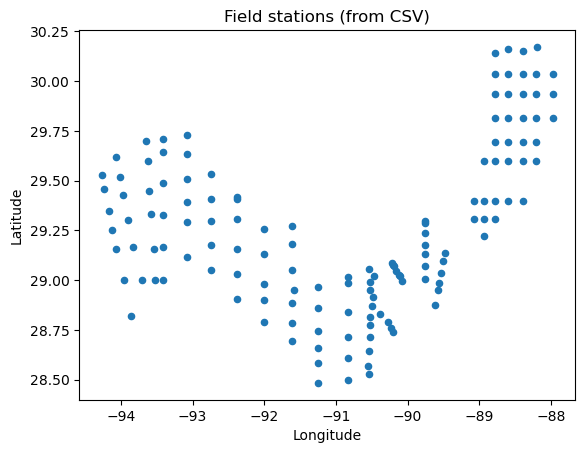

RuntimeError: Set EARTHDATA_USERNAME and EARTHDATA_PASSWORD in your environment.

In [1]:
# PACE Level-3 starter: simple regional pull + quick plots

# --- Imports ---
import os
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import earthaccess
import xarray as xr

# --- Paths ---
# Local convention: ./data and ./output
# Hosted/ChatGPT environment: your uploaded CSV is at /mnt/data/lsu_hypoxia_2024.csv

DATA_DIR = Path("data")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV = DATA_DIR / "lsu_hypoxia_2024.csv"
if not INPUT_CSV.exists():
    INPUT_CSV = Path("/mnt/data/lsu_hypoxia_2024.csv")

print("INPUT_CSV:", INPUT_CSV.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

# --- Load field data ---
field = pd.read_csv(INPUT_CSV, encoding="ISO-8859-1").copy()

COL_DATE = "Date"
COL_TIME = "Time CTD Cast began (UTC)"
COL_STATION = "Station"
COL_LAT = "Lat"
COL_LON = "Long"
COL_CHL = "Surface Chl ( µg/L)"

def parse_field_datetime_utc(date_str: str, time_str: str) -> datetime:
    dt = datetime.strptime(f"{date_str} {time_str}", "%m/%d/%Y %H:%M")
    return dt.replace(tzinfo=timezone.utc)

field["field_time_utc"] = [
    parse_field_datetime_utc(d, t)
    for d, t in zip(field[COL_DATE].astype(str), field[COL_TIME].astype(str))
]
field["field_date_utc"] = field["field_time_utc"].dt.date

display(field.head(3))
print("Rows:", len(field))
print("Date range:", field['field_time_utc'].min(), "→", field['field_time_utc'].max())

# --- Compute bbox around your stations (with padding) ---
lat_min = float(field[COL_LAT].min())
lat_max = float(field[COL_LAT].max())
lon_min = float(field[COL_LON].min())
lon_max = float(field[COL_LON].max())

PAD = 1.0  # degrees
bbox = (lon_min - PAD, lat_min - PAD, lon_max + PAD, lat_max + PAD)  # W,S,E,N

print("BBox (W,S,E,N):", bbox)

plt.figure()
plt.scatter(field[COL_LON], field[COL_LAT], s=20)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Field stations (from CSV)")
plt.show()

# --- Earthdata login (env vars) ---
if not os.environ.get("EARTHDATA_USERNAME") or not os.environ.get("EARTHDATA_PASSWORD"):
    raise RuntimeError("Set EARTHDATA_USERNAME and EARTHDATA_PASSWORD in your environment.")

earthaccess.login(strategy="environment")

# --- Discover PACE OCI Level-3 collections in your Earthdata view ---
collections = list(earthaccess.search_datasets(keyword="PACE OCI L3"))
print("Collections found:", len(collections))

rows = []
for c in collections[:60]:
    umm = getattr(c, "umm", None)
    meta = getattr(c, "meta", None)
    if isinstance(umm, dict) and isinstance(meta, dict):
        rows.append({
            "ShortName": umm.get("ShortName"),
            "Version": umm.get("Version"),
            "EntryTitle": umm.get("EntryTitle"),
            "Provider": meta.get("provider-id"),
            "ConceptId": meta.get("concept-id"),
        })

df_col = pd.DataFrame(rows).drop_duplicates()
display(df_col.head(30))

# --- Pick a Level-3 collection automatically (simple heuristic) ---
# You can override CHOSEN_SHORTNAME manually if the auto-pick isn't what you want.

CHOSEN_SHORTNAME = None
preferred_substrings = ["BGC", "CHL", "OC", "AOP", "RRS"]

for sub in preferred_substrings:
    m = df_col[df_col["ShortName"].astype(str).str.contains(sub, case=False, na=False)]
    if len(m) > 0:
        CHOSEN_SHORTNAME = m.iloc[0]["ShortName"]
        break

if CHOSEN_SHORTNAME is None and len(df_col) > 0:
    CHOSEN_SHORTNAME = df_col.iloc[0]["ShortName"]

print("CHOSEN_SHORTNAME:", CHOSEN_SHORTNAME)

# Manual override example:
# CHOSEN_SHORTNAME = "PACE_OCI_L3M_BGC"

# --- Choose a target day (first field date) ---
target_day = field["field_date_utc"].min()

t0 = datetime(target_day.year, target_day.month, target_day.day, 0, 0, 0, tzinfo=timezone.utc)
t1 = datetime(target_day.year, target_day.month, target_day.day, 23, 59, 59, tzinfo=timezone.utc)

print("Target day:", target_day, "UTC window:", t0.isoformat(), "→", t1.isoformat())

# --- Search granules (day window; fallback to month window) ---
def search_l3(short_name: str, start_iso: str, end_iso: str, bbox_wsen):
    return list(
        earthaccess.search_data(
            short_name=short_name,
            temporal=(start_iso, end_iso),
            bounding_box=bbox_wsen,
        )
    )

results = search_l3(CHOSEN_SHORTNAME, t0.isoformat(), t1.isoformat(), bbox)

if len(results) == 0:
    # Try month window
    month_start = datetime(target_day.year, target_day.month, 1, 0, 0, 0, tzinfo=timezone.utc)
    if target_day.month == 12:
        month_end = datetime(target_day.year + 1, 1, 1, 0, 0, 0, tzinfo=timezone.utc) - pd.Timedelta(seconds=1)
    else:
        month_end = datetime(target_day.year, target_day.month + 1, 1, 0, 0, 0, tzinfo=timezone.utc) - pd.Timedelta(seconds=1)

    print("No day granules; trying month window:", month_start.isoformat(), "→", month_end.isoformat())
    results = search_l3(CHOSEN_SHORTNAME, month_start.isoformat(), month_end.isoformat(), bbox)

print("Granules found:", len(results))
if results:
    print("Example granule:", results[0])

# --- Open 1 granule and inspect variables ---
if len(results) == 0:
    raise RuntimeError(
        "No Level-3 granules found for your bbox/time with the chosen short_name. "
        "Pick another ShortName from df_col and set CHOSEN_SHORTNAME manually."
    )

files = list(earthaccess.open(results[:1]))
print("Opened file objects:", len(files))

# Open with xarray (try h5netcdf then netcdf4)
try:
    ds = xr.open_dataset(files[0], engine="h5netcdf")
except Exception:
    ds = xr.open_dataset(files[0], engine="netcdf4")

print(ds)

print("\nVariables (first 80):")
print(list(ds.variables)[:80])

# --- Pick a variable to plot/match (simple) ---
CANDIDATES = ["chlor_a", "chl", "nflh", "avw", "kd_490", "bbp_443"]

PLOT_VAR = None
for v in CANDIDATES:
    if v in ds.variables:
        PLOT_VAR = v
        break

if PLOT_VAR is None:
    coordish = set(ds.coords) | {"lat", "lon", "latitude", "longitude", "time"}
    noncoord = [v for v in ds.variables if v not in coordish]
    PLOT_VAR = noncoord[0] if noncoord else None

print("PLOT_VAR:", PLOT_VAR)
if PLOT_VAR is None:
    raise RuntimeError("Could not choose a plot variable. Inspect ds.variables and set PLOT_VAR manually.")

# --- Plot the Level-3 field over your bbox + station overlay ---
lat_name = "lat" if "lat" in ds.coords else ("latitude" if "latitude" in ds.coords else None)
lon_name = "lon" if "lon" in ds.coords else ("longitude" if "longitude" in ds.coords else None)
if lat_name is None or lon_name is None:
    raise RuntimeError("Dataset does not have simple 1D lat/lon coords; inspect ds.coords.")

lats = ds[lat_name].values
lons = ds[lon_name].values

# Handle 0..360 longitudes
w, s, e, n = bbox
lon_pts = field[COL_LON].to_numpy()

if np.nanmax(lons) > 180:
    lon_pts = lon_pts % 360.0
    if w < 0:
        w = w % 360.0
        e = e % 360.0

lat_mask = (lats >= s) & (lats <= n)
lon_mask = (lons >= w) & (lons <= e)

sub = ds[PLOT_VAR].sel({lat_name: lats[lat_mask], lon_name: lons[lon_mask]})

plt.figure()
plt.pcolormesh(sub[lon_name], sub[lat_name], sub.values, shading="auto")
plt.colorbar(label=PLOT_VAR)
plt.scatter(lon_pts, field[COL_LAT].to_numpy(), s=20)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"PACE L3: {PLOT_VAR} (subset) + field stations")
plt.show()

# --- Nearest-grid matchups at stations (quick look) ---
def nearest_idx(arr1d: np.ndarray, value: float) -> int:
    return int(np.argmin(np.abs(arr1d - value)))

grid = ds[PLOT_VAR]
vals = []

for _, r in field.iterrows():
    lat = float(r[COL_LAT])
    lon = float(r[COL_LON])

    if np.nanmax(lons) > 180 and lon < 0:
        lon = lon % 360.0

    i_lat = nearest_idx(lats, lat)
    i_lon = nearest_idx(lons, lon)

    v = float(grid.isel({lat_name: i_lat, lon_name: i_lon}).values)
    vals.append(v)

field["pace_l3_nearest"] = vals

plt.figure()
plt.scatter(field[COL_CHL], field["pace_l3_nearest"], s=20)
plt.xlabel("Field Surface Chl (µg/L)")
plt.ylabel(f"PACE L3 {PLOT_VAR} (native units)")
plt.title("Quick matchup (nearest grid cell)")
plt.show()

display(field[[COL_STATION, "field_time_utc", COL_LAT, COL_LON, COL_CHL, "pace_l3_nearest"]].head(10))

# --- Save outputs ---
out_table = OUTPUT_DIR / "pace_l3_quick_matchups.csv"
field[[COL_STATION, "field_time_utc", COL_LAT, COL_LON, COL_CHL, "pace_l3_nearest"]].to_csv(out_table, index=False)
print("Wrote:", out_table.resolve())
